In [1]:
# MPI

import os
import sys

# Add the '../sources' directory to the Python path using source_dir,
# and add its parent directory as well.
source_dir = os.path.abspath(os.path.join("..", "sources"))
parent_dir = os.path.abspath(os.path.join(source_dir, os.pardir))

for directory in [source_dir, parent_dir]:
    if directory not in sys.path:
        sys.path.insert(0, directory)


In [2]:

print(f"Included '{source_dir}' and its parent directory '{parent_dir}' in sys.path.")
## Define the materials
from sources.photonic_crystal_maker import Material
from sources.photonic_crystal_maker import Lattice, Geometry, PhotonicCrystal, ScriptParam, ScriptParamVector3
from sources.mpb_configurator import MPBSchemeConfigurator  
import meep as mp
from sources.photonic_crystal_maker import Lattice, Geometry, PhotonicCrystal
from sources.mpb_configurator import *


n_InP = 3.1

eps = round(n_InP**2,2)
print("Epsilon of InP: ", eps)
InP = Material(epsilon = eps)
air = Material(epsilon = 1)
## Simulation Name: 
name = "test_changes"






## Define the geometry
radius1 = ScriptParam("r1", 0.3)
radius2 = ScriptParam("r2", 0.2)
height_supercell = 3
height_slab = ScriptParam("h", 0.4)
slab_block_size = ScriptParamVector3(1e20, 1e20, "h", z_def = 0.4)

## Define the lattice
lattice_2D = Lattice(type="TXY")
lattice_slab = Lattice(type="TXY", size=mp.Vector3(1, 1, height_supercell))
centers = lattice_2D.get_centers()
k_points = lattice_2D.get_high_symmetry_k_points()



bulk_2D = Geometry(geom_type=mp.Block, params={"center": mp.Vector3(0,0,0), "size": mp.Vector3(1e20, 1e20, 1e20), "material": InP})
bulk_slab = Geometry(geom_type=mp.Block, params={"center": mp.Vector3(0,0,0), "size": slab_block_size, "material": InP})
hole1_2D = Geometry(geom_type=mp.Cylinder, params={"center": centers[0], "radius": radius1, "height": 1e20, "material": air})
hole2_2D = Geometry(geom_type=mp.Cylinder, params={"center": centers[1], "radius": radius2, "height": 1e20, "material": air})
hole1_slab = Geometry(geom_type=mp.Cylinder, params={"center": centers[0], "radius": radius1, "height": height_slab, "material": air})
hole2_slab = Geometry(geom_type=mp.Cylinder, params={"center": centers[1], "radius": radius2, "height": height_slab, "material": air})

photonic_crystal_2D = PhotonicCrystal(lattice=lattice_2D, atoms=[bulk_2D, hole1_2D, hole2_2D])
photonic_crystal_slab = PhotonicCrystal(lattice=lattice_slab, atoms=[bulk_slab, hole1_slab, hole2_slab])

## Define the simulation

configuration_options = dict(
    resolution = 32, 
    num_bands=8,
    k_points=k_points["k_points_values"],
    k_point_interpolation_factor=20, 
    extra_runner_command = "(output-at-kpoint (vector3 0 0 0) fix-efield-phase output-efield-z)"
)



mpb_configuration_2D = MPBSchemeConfigurator(photonic_crystal_2D, ["te", "tm"], **configuration_options)
mpb_configuration_slab = MPBSchemeConfigurator(photonic_crystal_slab, ["zeven", "zodd"], **configuration_options)
script_2D = mpb_configuration_2D.get_scheme_config(join_newline=True)
script_slab = mpb_configuration_slab.get_scheme_config(join_newline=True)

Included '/zhome/2f/7/202918/phc_nzi/sources' and its parent directory '/zhome/2f/7/202918/phc_nzi' in sys.path.
Epsilon of InP:  9.61
Found script param: size with value: (vector3 1e+20 1e+20 h)
Found script param: radius with value: r1
Found script param: radius with value: r2
Found script param: radius with value: r1
Found script param: height with value: h
Found script param: radius with value: r2
Found script param: height with value: h
COMMANDS ['(define-param r1 0.3)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 0.4)', '(define-param r1 0.3)', '(define-param r2 0.2)']


In [3]:
print(script_slab)

(set! num-bands 8)
(set! resolution 32)
(set! k-points (list (vector3 0.0 0.0 0.0) (vector3 0.0 0.5 0.0) (vector3 -0.3333333333333333 0.3333333333333333 0.0) (vector3 0.0 0.0 0.0)))
(set! k-points (interpolate 20 k-points))
(define-param h 0.4)
(define-param r1 0.3)
(define-param r2 0.2)
(set! geometry-lattice (make lattice (size 1.0 1.0 3.0)  (basis1  (vector3 1.0 0.0 0.0)) (basis2  (vector3 0.5000000000000001 0.8660254037844388 0.0)) ))
(set! geometry (list 
 (make block (center (vector3 0.0 0.0 0.0))
  (size (vector3 1e+20 1e+20 h))
  (material (make dielectric (epsilon 9.61))))
 (make cylinder (center (vector3 0.3333333333333333 0.3333333333333333 0.0))
  (radius r1)
  (height h)
  (material (make dielectric (epsilon 1))))
 (make cylinder (center (vector3 0.6666666666666666 0.6666666666666666 0.0))
  (radius r2)
  (height h)
  (material (make dielectric (epsilon 1))))
))
(run-zeven (output-at-kpoint (vector3 0 0 0) fix-efield-phase output-efield-z))
(run-zodd (output-at-kpoint (vec

In [4]:

from sources.mpi_differential_evolution import MPIDiffEvoSimulation
from sources.simulation_handler import Simulation
from sources.simulation_handler import SimulationViewer

# Create your Simulation instance.
simulation_2D = Simulation(simulation_name=name+"_2D",
                 script=script_2D,
                 log_level = Simulation.WARNING)

simulation_slab = Simulation(simulation_name=name+"_slab",
                    script=script_slab,
                    log_level = Simulation.WARNING)

In [5]:
simulation_2D.run_hpc(mpb_command_line_params={"r1":0.10, "r2":0.339})


{2: 0.408168, 3: 0.408183, 4: 0.408233}


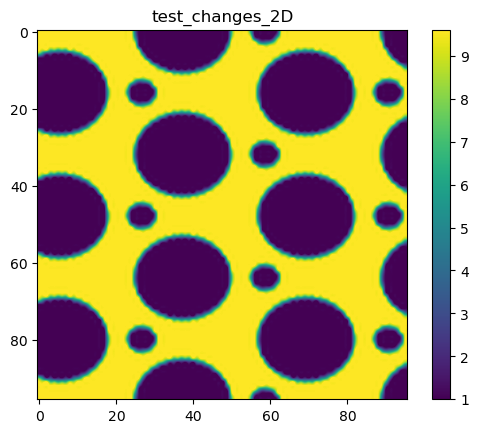

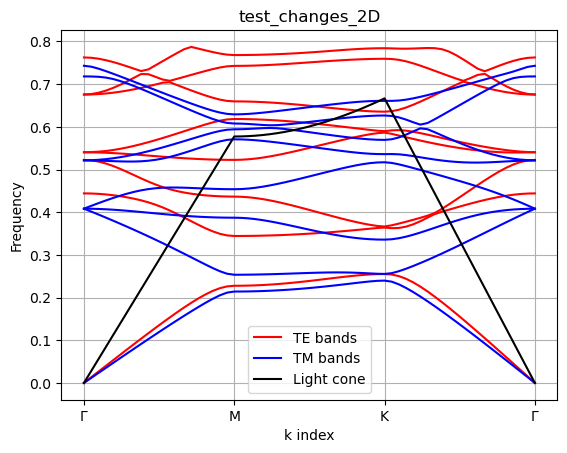

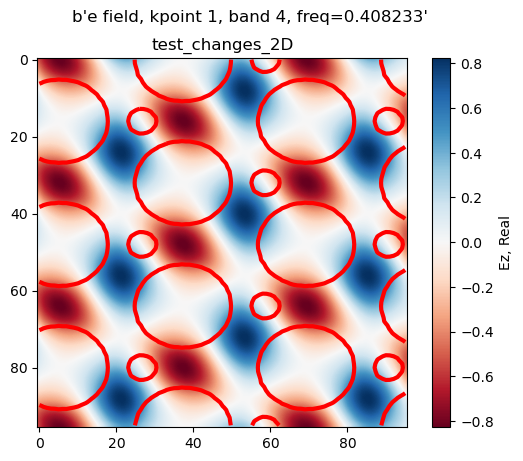

In [6]:

sim = simulation_2D 
df =sim.load_frequency_data("tm")
freqs = sim.get_frequencies_by_band(df, "tm")
print(freqs)
cost = abs(freqs[4] - freqs[2])


viewer = SimulationViewer(sim)
conversion_options = dict(
    periods = 3, 
    rectify = True, 
)
viewer.newfig()
viewer.plot_epsilon_2d(conversion_options=conversion_options)
viewer.show()
viewer.plot_band_diagram("te", colors = "red", k_points_path=k_points)
viewer.plot_band_diagram("tm", colors = "blue", k_points_path=k_points)
viewer.plot_light_cone(df = df) 
viewer.show()
viewer.plot_field_data(1,4,"z","tm", "e", "real", conversion_options=conversion_options, overlay_epsilon=True)

In [7]:
simulation_slab.run_hpc_lsf(mpb_command_line_params={"r1":0.10, "r2":0.339}, num_procs=20)


{2: 0.320762, 3: 0.320774, 4: 0.538763}


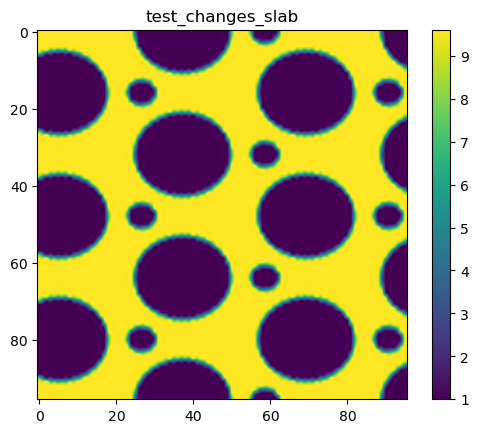

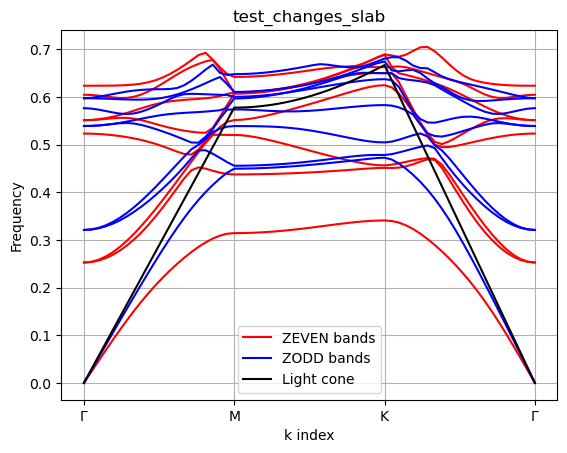

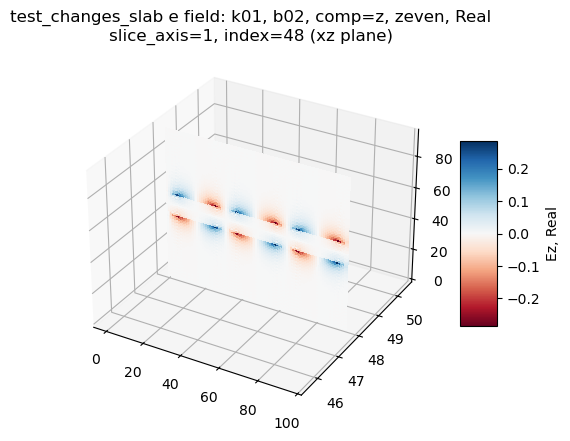

In [8]:

sim = simulation_slab
df =sim.load_frequency_data("zodd")
freqs = sim.get_frequencies_by_band(df, "zodd")
print(freqs)
cost = abs(freqs[4] - freqs[2])


viewer = SimulationViewer(sim)
conversion_options = dict(
    periods = (3, 3, 1), 
    rectify = True, 
)
viewer.newfig()
viewer.plot_epsilon_2d(conversion_options=conversion_options)
viewer.show()
viewer.plot_band_diagram("zeven", colors = "red", k_points_path=k_points)
viewer.plot_band_diagram("zodd", colors = "blue", k_points_path=k_points)
viewer.plot_light_cone(df = df) 
viewer.show()
viewer.plot_field_data(1,2,"z","zeven", "e", "real", conversion_options=conversion_options, overlay_epsilon=False, slice_axis=1)

viewer.show()

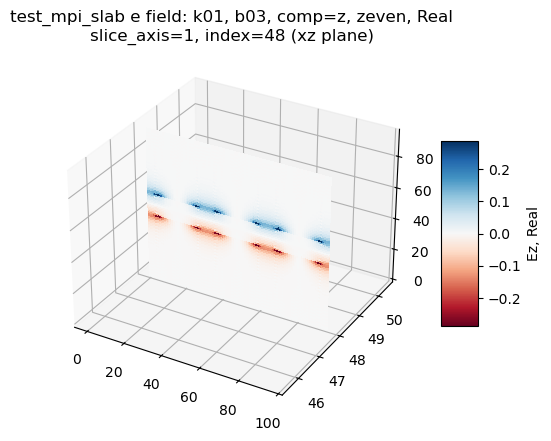

In [36]:
viewer.newfig()
viewer.plot_field_data(1,3,"z","zeven", "e", "real", conversion_options=conversion_options, overlay_epsilon=False, slice_axis=1)